### Cell 1: Load the Data & Setup NLTK

In [1]:
!pip install --upgrade transformers accelerate

In [2]:
import transformers

print(transformers.__version__)

5.9.0


In [3]:
import pandas as pd
import numpy as np
import torch
import nltk

from sklearn.model_selection import train_test_split

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
from transformers import EarlyStoppingCallback

Download stopwords

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mayur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

1. Load the cleaned data we saved from the previous notebook

In [5]:
print("Loading cleaned data...")
df = pd.read_csv('cleaned_news_data.csv')
df.head()

Loading cleaned data...


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",1


Saftey check: Sometimes saving/loading to CSV creates nulls if a text was completely empty

In [6]:
df = df.dropna().reset_index(drop=True)

print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (44689, 5)


In [7]:
df = df.sample(5000, random_state=42)

In [8]:
# Features and Labels

X = df['text']

Y = df['label']

# Train Test Split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [9]:
# Load Tokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)

# Tokenization Function

def tokenize_function(texts):

    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=128
    )
# Tokenize

train_encodings = tokenize_function(X_train)

test_encodings = tokenize_function(X_test)

In [10]:
class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings

        self.labels = labels.tolist()

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [11]:
train_dataset = NewsDataset(
    train_encodings,
    Y_train
)

test_dataset = NewsDataset(
    test_encodings,
    Y_test
)

In [12]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy
    }

In [15]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    num_train_epochs=3,

    per_device_train_batch_size=4,

    per_device_eval_batch_size=4,

    warmup_steps=50,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=50,

    save_total_limit=2,

    fp16=False
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [17]:
trainer.train()

c:\Niyati-AIML\Project\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.000080,0.009281,0.999000
2,0.000053,0.009722,0.999000
3,0.000038,0.009963,0.999000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Niyati-AIML\Project\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Niyati-AIML\Project\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.015387946430205678, metrics={'train_runtime': 3606.8762, 'train_samples_per_second': 3.327, 'train_steps_per_second': 0.832, 'total_flos': 397402195968000.0, 'train_loss': 0.015387946430205678, 'epoch': 3.0})

In [18]:
print("Generating predictions...")

predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)

print("Predictions complete!")

Generating predictions...


c:\Niyati-AIML\Project\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predictions complete!


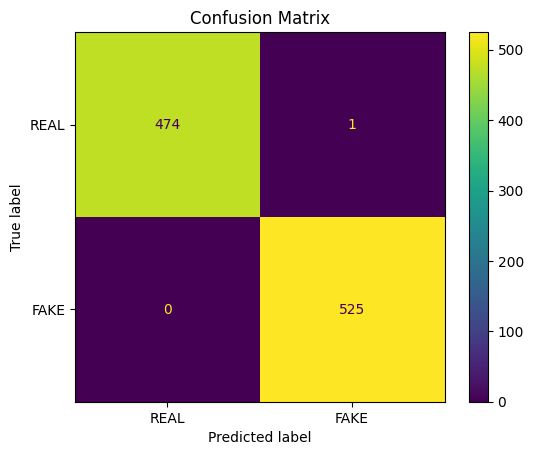

In [19]:
cm = confusion_matrix(
    Y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["REAL", "FAKE"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [20]:
accuracy = accuracy_score(
    Y_test,
    y_pred
)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.90%


In [21]:
report = classification_report(
    Y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       475
           1       1.00      1.00      1.00       525

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



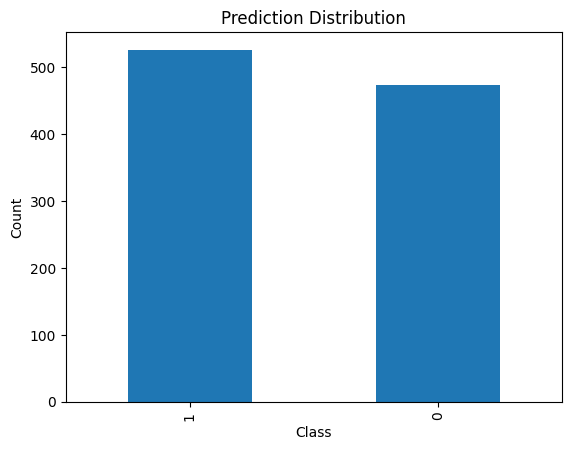

In [22]:
import pandas as pd

prediction_df = pd.DataFrame({

    "Actual": Y_test.values,

    "Predicted": y_pred
})

prediction_df["Predicted"].value_counts().plot(
    kind="bar"
)

plt.title("Prediction Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [23]:
model.save_pretrained("distilbert_model")

tokenizer.save_pretrained("distilbert_tokenizer")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert_tokenizer\\tokenizer_config.json',
 'distilbert_tokenizer\\tokenizer.json')